## CMPE-257, Machine Learning, Summer 2025
## Week 7: Tree-based Methods
In this workbook, you will be exploring decision trees for classification

- decision tree classifier
- random forest classifier
- gradient boosting classifier

In [ ]:
# YOUR NAME: Quoc Dung Lam

In [1]:
# loads required modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
# Loads the "iris_plants_dataset" and displays its description

iris = datasets.load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

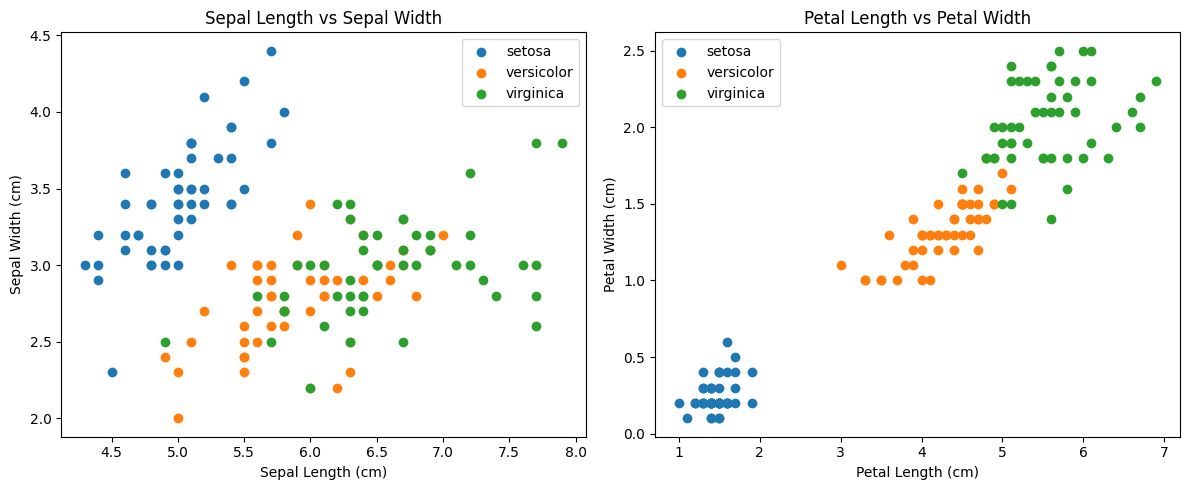

In [3]:
# Excercise #1: generate two cross-plots (sepal lenght vs sepal width, and petal lenght vs petal width)
# and color each data point according to its corresponding class

X = iris.data
y = iris.target
target_names = iris.target_names

# Create a scatter plot for sepal length vs sepal width
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for target in range(len(target_names)):
    plt.scatter(
        X[y == target, 0],  # sepal length
        X[y == target, 1],  # sepal width
        label=target_names[target]
    )
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()

# Create a scatter plot for petal length vs petal width
plt.subplot(1, 2, 2)
for target in range(len(target_names)):
    plt.scatter(
        X[y == target, 2],  # petal length
        X[y == target, 3],  # petal width
        label=target_names[target]
    )
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()

plt.tight_layout()
plt.show()



In [ ]:
# What are your main observations from exercise #1?
# For Left Plot, Setosa cluster is separated clearly, while Versicolor and Virginica overlap significantly in this feature space.
# This suggests that sepal features alone are not sufficient for clear classification.
# For Right Plot, all clusters are separated nicely, make Petal features are highly useful for classification.

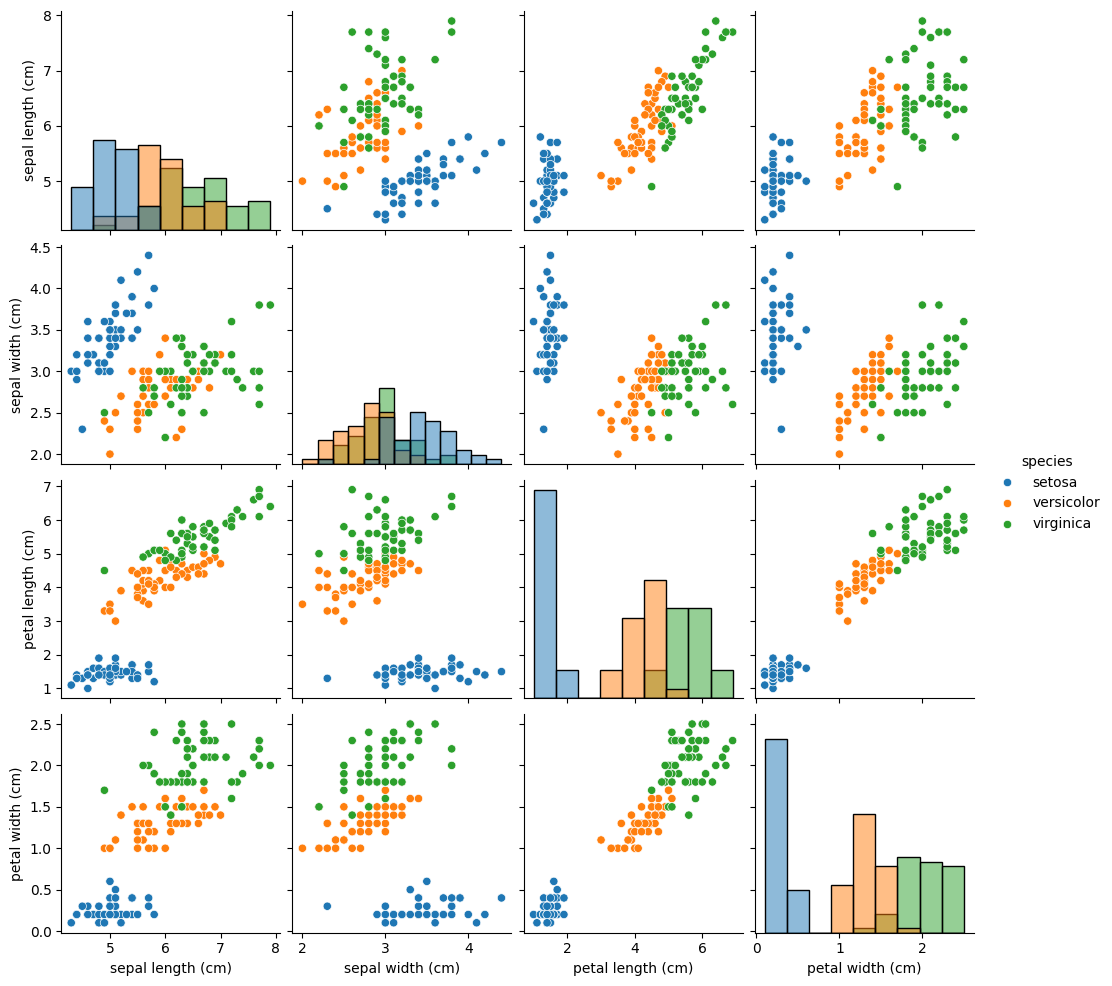

In [4]:
# Exercise #2: use sns.pairplot() to generate the pair-plots for the features in the dataset, again
# color data points according to their corresponding class

# Create a DataFrame for seaborn
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({i: name for i, name in enumerate(iris.target_names)})

# Generate pairplot
sns.pairplot(iris_df, hue='species', diag_kind='hist')


In [ ]:
# What are your main observations from exercise #2?

# Setosa forms a distinct cluster in almost every feature. It is clearly linearly separable from the other two classes.
# Versicolor and Virginica show overlap in several plots. Best Separation is visible in Petal Length vs Petal Width, and Petal Width vs Sepal Length

## PART 1: Decision Tree Classifier

In [ ]:
# Splits the data into two subsets of equal size (for training and testing purposes), trains a single 
# decision tree classifier, and displays the tree with the main node properties

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
dtc = DecisionTreeClassifier()
dtc.fit(trn_feat,trn_tgt)

fig,ax = plt.subplots(1,1,figsize=(10,8))
tree.plot_tree(dtc,fontsize=8,ax=ax,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()

In [ ]:
# Exercise #3: use dtc.predict() and classification_report() to compute predictions and their
# corresponing scores for both the training and testing datasets

# add your code here...


In [ ]:
# What are your main observations from exercise #3?
# <write your comments here>

In [ ]:
# Exercise #4: use the same data split from exercise #1 to train a new decision classifier but, this time,
# use the ccp_alpha parameter to conduct cost complexity pruning (i.e. weakest link pruning). Use alpha = 0.02

# add your code here...


In [ ]:
# What are your main observations? How the resulting tree compares to the previous one?
# <write your comments here>

In [ ]:
# Exercise #4 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets 

# add your code here...


In [ ]:
# What are your main conclusions from exercise #4? How these results compare to the ones from exercise #3?
# <write your comments here>

In [ ]:
# Exercise #5: repeat exercise #4 but use alpha = 0.05 this time

# add your code here...


In [ ]:
# What are your main observations? How the resulting tree compares to the previous ones?
# <write your comments here>

In [ ]:
# Exercise #5 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets  

# add your code here...


In [ ]:
# What are your main conclusions from exercise #5? How these results compare to the ones from exercises #3 and #4?
# <write your comments here>

## PART 2: Random Forest Classifier

In [ ]:
# Exercise #6: use RandomForestClassifier() with parameterds n_estimators = 200 and random_state = 1 to 
# train a random forest ensemble and report the classification scores on both the training and testing 
# datasets (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

# add your code here...


In [ ]:
# What are your main observations from exercise #6?
# <write your comments here>

In [ ]:
# Exercise #7: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'max_depth', 'max_features' and 'n_estimators' (use
# also random_state = 1)

rfc_param = {'ccp_alpha':[0.03,0.05],'max_depth':[8,9,10], 'max_features':[1,2], 'n_estimators':[200,300]}

# add your code here...


In [ ]:
# What are your main observations from exercise #7?
# <write your comments here>

In [ ]:
# Exercise #7 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# RandomForestClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)

# add your code here...


In [ ]:
# What are your main observations from exercise #7? How these results compare with those from exercise #6?
# <write your comments here>

## PART 3: Gradient Boosting Classifier

In [ ]:
# Exercise #8: use GradientBoostingClassifier() with parameterds n_estimators = 10 and random_state = 1 to 
# train a boosting ensemble and report the classification scores on both the training and testing datasets
# (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

# add your code here...


In [ ]:
# What are your main observations from exercise #8?
# <write your comments here>

In [ ]:
# Exercise #9: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'learning_rate', 'max_depth' and 'n_estimators' (use
# also random_state = 1)

gbc_param = {'ccp_alpha':[0.01,0.03,0.05], 'learning_rate':[0.005,0.007,0.01], 'max_depth':[1,2,3], 'n_estimators':[10,20,30]}

# add your code here...


In [ ]:
# What are your main observations from exercise #9?
# <write your comments here>

In [ ]:
# Exercise #9 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# GradientBoostingClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)

# add your code here...


In [ ]:
# What are your main observations from exercise #9? How these results compare with those from exercise #8?
# <write your comments here>